In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

In [2]:
import pandas as pd

# 1) Read the NDJSON into a DataFrame
df = pd.read_json("yelp_photos/photos.json", lines=True)

# 2) Write out to CSV (no index column)
df.to_csv("yelp_photos/photos.csv", index=False)

print("CSV file created successfully!")


CSV file created successfully!


In [3]:
csv_file = "yelp_photos/photos.csv"  # Update if your CSV has a different name
df = pd.read_csv(csv_file)
print("Total rows in CSV:", len(df))

# Randomly take 1000 rows
df_sample = df.sample(n=26000, random_state=42).copy()
df_sample.reset_index(drop=True, inplace=True)
print("Sampled rows:", len(df_sample))

Total rows in CSV: 200100
Sampled rows: 26000


In [4]:
def get_image_path(photo_id, folder="yelp_photos/photos"):
    # Adjust the folder name or file extension if needed
    return os.path.join(folder, f"{photo_id}.jpg")

df_sample["img_path"] = df_sample["photo_id"].apply(get_image_path)

valid_rows = []
for _, row in df_sample.iterrows():
    path = row["img_path"]
    if os.path.exists(path):
        img = cv2.imread(path)
        if img is not None:
            valid_rows.append(row)

df_sample_good = pd.DataFrame(valid_rows)
df_sample_good.reset_index(drop=True, inplace=True)
print("Valid (good) images after filtering:", len(df_sample_good))

if len(df_sample_good) == 0:
    raise ValueError("No valid images found. Check your paths or file names!")

Valid (good) images after filtering: 25989


In [5]:
label_encoder = LabelEncoder()
df_sample_good["label_encoded"] = label_encoder.fit_transform(df_sample_good["label"])

num_classes = df_sample_good["label_encoded"].nunique()
print("Number of classes:", num_classes)
print("Class names:", label_encoder.classes_)

Number of classes: 5
Class names: ['drink' 'food' 'inside' 'menu' 'outside']


In [6]:
train_df, test_df = train_test_split(
    df_sample_good,
    test_size=0.2,
    stratify=df_sample_good["label_encoded"],
    random_state=42
)
print("Train set size:", len(train_df))
print("Test set size :", len(test_df))

Train set size: 20791
Test set size : 5198


In [7]:
IMG_SIZE = (224, 224)

def load_image(img_path, target_size=IMG_SIZE):
    """
    Reads an image from disk, converts to RGB, resizes,
    and returns a float32 array in [0,1].
    """
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    return img

def make_dataset(dataframe, images_folder="yelp_photos/photos", batch_size=32, shuffle=True):
    file_paths = []
    labels = []

    for _, row in dataframe.iterrows():
        path = row["img_path"]  # We already have the path in this column
        label_id = row["label_encoded"]
        file_paths.append(path)
        labels.append(label_id)

    file_paths = np.array(file_paths)
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def load_and_preprocess(path, label):
        image = tf.py_function(
            func=lambda x: load_image(x.numpy().decode("utf-8")),
            inp=[path],
            Tout=tf.float32
        )
        image.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
        return image, label

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [8]:
train_dataset = make_dataset(train_df, batch_size=32, shuffle=True)
test_dataset  = make_dataset(test_df,  batch_size=32, shuffle=False)

In [9]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,077 (49.36 MB)

 Trainable params: 12,939,077 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 5
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset
)


Epoch 1/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 215s 296ms/step - accuracy: 0.7048 - loss: 0.9354 - val_accuracy: 0.8274 - val_loss: 0.4951
Epoch 2/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 249s 305ms/step - accuracy: 0.8385 - loss: 0.4676 - val_accuracy: 0.8474 - val_loss: 0.4343
Epoch 3/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 231s 289ms/step - accuracy: 0.8845 - loss: 0.3284 - val_accuracy: 0.8513 - val_loss: 0.4520
Epoch 4/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 230s 280ms/step - accuracy: 0.9338 - loss: 0.1858 - val_accuracy: 0.8476 - val_loss: 0.5055
Epoch 5/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 246s 311ms/step - accuracy: 0.9669 - loss: 0.1030 - val_accuracy: 0.8449 - val_loss: 0.6335


In [12]:
# Classification report (precision/recall/F1)
print("Classification Report:")
class_names = label_encoder.classes_
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

       drink       0.63      0.53      0.58       400
        food       0.92      0.94      0.93      2826
      inside       0.78      0.84      0.81      1452
        menu       0.71      0.12      0.20        42
     outside       0.70      0.60      0.65       478

    accuracy                           0.84      5198
   macro avg       0.75      0.61      0.63      5198
weighted avg       0.84      0.84      0.84      5198



In [13]:
def build_model(hp):
    """
    Build a Keras model with some hyperparameters for demonstration.
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(224,224,3)))
    
    # First Conv block
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_1', values=[32, 64]), 
        kernel_size=(3,3), 
        activation='relu', 
        padding='same')
    )
    model.add(layers.MaxPooling2D((2,2)))
    
    # Second Conv block
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_2', values=[64, 128]), 
        kernel_size=(3,3), 
        activation='relu', 
        padding='same')
    )
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    
    # Dense layer with tunable units
    model.add(layers.Dense(
        hp.Int('dense_units', min_value=64, max_value=256, step=64), 
        activation='relu')
    )
    
    # Dropout rate
    model.add(layers.Dropout(hp.Float('dropout_rate', 0.2, 0.5, step=0.1)))
    
    # Final layer: number of classes in your dataset
    # You must define 'num_classes' from your label encoding
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    # Learning rate
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [14]:
# RandomSearch
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=5,              
    executions_per_trial=1,    
    directory='my_dir',
    project_name='yelp_tuning'
)

# Run the tuner search. Adjust epochs as needed.
tuner.search(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

# Print a summary of the results
tuner.results_summary()


Trial 5 Complete [00h 59m 31s]
val_accuracy: 0.8291650414466858

Best val_accuracy So Far: 0.8291650414466858
Total elapsed time: 03h 25m 49s
Results summary
Results in my_dir\yelp_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 4 summary
Hyperparameters:
filters_1: 64
filters_2: 128
dense_units: 128
dropout_rate: 0.30000000000000004
learning_rate: 0.001
Score: 0.8291650414466858

Trial 3 summary
Hyperparameters:
filters_1: 64
filters_2: 64
dense_units: 128
dropout_rate: 0.2
learning_rate: 0.001
Score: 0.8245478868484497

Trial 0 summary
Hyperparameters:
filters_1: 64
filters_2: 64
dense_units: 192
dropout_rate: 0.2
learning_rate: 0.0001
Score: 0.7300000190734863

Trial 2 summary
Hyperparameters:
filters_1: 32
filters_2: 128
dense_units: 256
dropout_rate: 0.30000000000000004
learning_rate: 0.01
Score: 0.7266256213188171

Trial 1 summary
Hyperparameters:
filters_1: 64
filters_2: 128
dense_units: 128
dropout_rate: 0.4
learning_rate: 0.0001
Score: 0.69

In [15]:
# Get the best hyperparameters (optional)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hps.values)

# Build the model with these best hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]

best_model.fit(train_dataset, validation_data=test_dataset, epochs=5)


Best hyperparameters: {'filters_1': 64, 'filters_2': 128, 'dense_units': 128, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.001}
Epoch 1/5


C:\Users\tanik\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


650/650 ━━━━━━━━━━━━━━━━━━━━ 455s 635ms/step - accuracy: 0.9057 - loss: 0.2756 - val_accuracy: 0.8321 - val_loss: 0.5639
Epoch 2/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 470s 655ms/step - accuracy: 0.9533 - loss: 0.1352 - val_accuracy: 0.8272 - val_loss: 0.8165
Epoch 3/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 438s 619ms/step - accuracy: 0.9786 - loss: 0.0665 - val_accuracy: 0.8068 - val_loss: 0.9170
Epoch 4/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 447s 620ms/step - accuracy: 0.9834 - loss: 0.0510 - val_accuracy: 0.8194 - val_loss: 1.0321
Epoch 5/5
650/650 ━━━━━━━━━━━━━━━━━━━━ 437s 614ms/step - accuracy: 0.9892 - loss: 0.0383 - val_accuracy: 0.8144 - val_loss: 1.1306


In [16]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_dataset:
    # Predict probabilities
    probs = best_model.predict(images)
    preds = np.argmax(probs, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.append(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.concatenate(y_probs, axis=0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

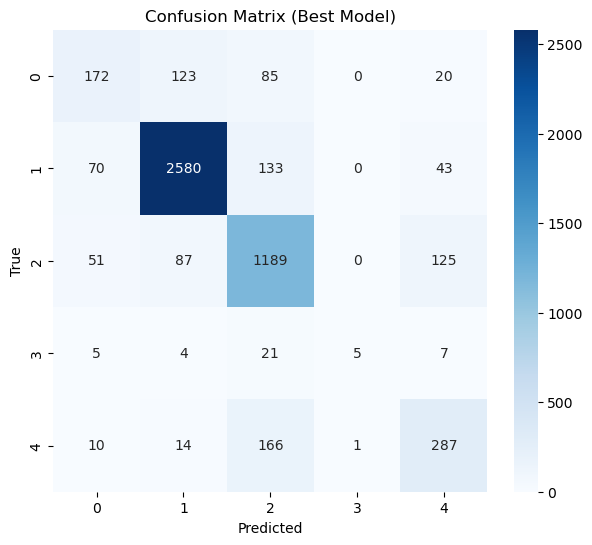

In [17]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [18]:
# Convert y_true to one-hot
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)

from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_true_onehot, y_probs, average='macro', multi_class='ovo')
print("Macro-Average AUC:", auc_score)


Macro-Average AUC: 0.9190067803405778


In [19]:
from sklearn.metrics import classification_report

# If you have the label_encoder:
# class_names = label_encoder.classes_
class_names = [f"Class {i}" for i in range(num_classes)]  # or adapt to real class names

print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

     Class 0       0.56      0.43      0.49       400
     Class 1       0.92      0.91      0.92      2826
     Class 2       0.75      0.82      0.78      1452
     Class 3       0.83      0.12      0.21        42
     Class 4       0.60      0.60      0.60       478

    accuracy                           0.81      5198
   macro avg       0.73      0.58      0.60      5198
weighted avg       0.81      0.81      0.81      5198



In [42]:
best_model.save("best_model_cnn.h5")
print("Best model saved to best_model.h5")

Best model saved to best_model.h5
